# V(D)J clustering

On the topic of finding clones/clonotypes, there are many ways used for clustering BCRs, almost all involving some measure based on sequence similarity. There are also a lot of very well established guidelines and criterias maintained by the BCR community. For example, *immcantation* uses a number of model-based [methods](https://changeo.readthedocs.io/en/stable/methods/clustering.html) that performs clustering of amino acid or nucleotide sequences based on predetermined thresholds (either user-selected or using a density-based approach).

Here, *dandelion* implements a convenient method to call clones using a simple nearest-neighbor approach that satisfies the criteria described below. But first, let's load the modules and files we need.

In [1]:
import os
import scanpy as sc
import dandelion as ddl

os.chdir("dandelion_tutorial")
sc.settings.verbosity = 3

In [2]:
# read in the previously saved file
vdj = ddl.read_zipddl("dandelion_results.zipddl")
vdj

Lazy Dandelion object with n_obs = 2496 and n_contigs = 5767
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [3]:
adata = sc.read_h5ad("adata.h5ad")
adata

AnnData object with n_obs × n_vars = 25063 × 1309
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'gmm_pct_count_clusters_keep', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_genotyped_VDJ_main', 'v_call_genotyped_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'lei

## Finding clones

The following is *dandelion*'s implementation of a rather conventional method to define clones, `ddl.tl.find_clones`. 

<div class="alert alert-info">

Clone definition criterion
    
<b>Clone definition is based on the following criterion:</b><br><br>

<b>I.</b> Identical V- and J-gene usage in the VDJ chain (IGH/TRB/TRD).<br><br>

<b>II.</b> Identical CDR3 junctional/CDR3 sequence length in the VDJ chain.<br><br>

<b>III.</b> VDJ chain junctional/CDR3 sequences attains a minimum of % sequence similarity, based on hamming distance. The similarity cut-off is tunable (default is 85%; change to 100% if analyzing TCR data).<br><br>

<b>IV.</b> VJ chain (IGK/IGL/TRA/TRG) usage. If cells within clones use different VJ chains, the clone will be split following the same conditions for VDJ chains in (1-3) as above.
</div>

### (Optional) Simplifying annotation calls.
This is an optional step to simplify the annotation calls. The `vdj.simplify()` will reduce the complexity of the gene names and strip the alleles. This impacts on how clones are defined (using simpler v/j calls) and also visualiation.

In [4]:
# original
vdj.data[["v_call_genotyped", "j_call", "c_call"]].collect()

v_call_genotyped,j_call,c_call
str,str,str
"""IGKV1-33*01,IGKV1D-33*01""","""IGKJ4*01""","""IGKC"""
"""IGHV1-69*01,IGHV1-69D*01""","""IGHJ3*02""","""IGHM"""
"""IGKV1-8*01""","""IGKJ1*01""","""IGKC"""
"""IGLV5-45*02""","""IGLJ3*02""","""IGLC3"""
"""IGHV1-2*02""","""IGHJ3*02""","""IGHM"""
…,…,…
"""IGHV1-46*01""","""IGHJ5*02""","""IGHM"""
"""IGHV1-69*01,IGHV1-69D*01""","""IGHJ6*02""","""IGHM"""
"""IGLV1-47*01""","""IGLJ3*02""","""IGLC3"""


In [5]:
vdj.simplify()
vdj.data[["v_call_genotyped", "j_call", "c_call"]].collect()

v_call_genotyped,j_call,c_call
str,str,str
"""IGKV1-33""","""IGKJ4""","""IGKC"""
"""IGHV1-69""","""IGHJ3""","""IGHM"""
"""IGKV1-8""","""IGKJ1""","""IGKC"""
"""IGLV5-45""","""IGLJ3""","""IGLC3"""
"""IGHV1-2""","""IGHJ3""","""IGHM"""
…,…,…
"""IGHV1-46""","""IGHJ5""","""IGHM"""
"""IGHV1-69""","""IGHJ6""","""IGHM"""
"""IGLV1-47""","""IGLJ3""","""IGLC3"""


In [6]:
# let's save this as a separate file
vdj.write_zipddl("dandelion_results_simplified.zipddl")

### Running `ddl.tl.find_clones`
The function will take a file path, a polars `DataFrame` (for example if you've used polars to read in the filtered file already), or a `DandelionPolars` class object. The default mode for calculation of junctional hamming distance is to use the CDR3 junction amino acid sequences, specified via the `key` option (`None` defaults to `junction_aa`). You can switch it to using CDR3 junction nucleotide sequences by specifying `key='junction'`.

<div class="alert alert-info">

`store_distances=True`

Setting `store_distances=True` will store the clone-level pairwise distance matrix as a CSR sparse matrix in `vdj.distances`. This is useful because `ddl.tl.generate_network` will automatically detect and reuse pre-computed distances from `.distances`, avoiding redundant recalculation. This can save significant time when running both `find_clones` and `generate_network` in sequence.
</div>

In [7]:
ddl.tl.find_clones(vdj, store_distances=True)
vdj.distances

Finding clonotypes
Using PyTorch backend with Apple Metal GPU


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 1162/1162 [00:02<00:00, 474.08it/s]
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 491/491 [00:00<00:00, 665.81it/s]


Storing distance matrix...


Building distance matrix (batched): 100%|██████████| 17/17 [00:00<00:00, 3353.08it/s]

Stored distances as CSR sparse matrix: (2496, 2496), density=0.69%
 finished: Updated Dandelion object: 
   'data', contig AIRR table
   'metadata', cell observations table
   'distances', sparse distance matrix
 (0:00:06)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 42995 stored elements and shape (2496, 2496)>

This will return a new column with the column name `'clone_id'` as per convention. If a file path is provided as input, it will also save the file automatically into the base directory of the file name. Otherwise, a `DandelionPolars` object will be returned.

<div class="alert alert-info">

Clonotype definition criterion

The `clone_id` follows an `VDJ_{A}_{B}_{C}_VJ_{D}_{E}_{F}` format and largely reflects the conditions above where:

    {A} indicates if the contigs use the same V and J genes in the VDJ chain.
    
    {B} indicates if junctional/CDR3 sequences are equal in length in the VDJ chain.
    
    {C} indicates if clones are split based on distance threshold for the VDJ chain.
    
    {D} indicates if the contigs use the same V and J genes in the VJ chain.
    
    {E} indicates if junctional/CDR3 sequences are equal in length in the VJ chain.
    
    {F} indicates if clones are split based on distance threshold for the VJ chain.
    
</div>

In [8]:
vdj.metadata.collect()

cell_id,clone_id,clone_id_rank,sample_id,productive_VDJ,productive_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,junction_VDJ,junction_VJ,junction_aa_VDJ,junction_aa_VJ,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,c_call_VDJ,c_call_VJ,umi_count_VDJ,umi_count_VJ,productive_VDJ_main,productive_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,junction_VDJ_main,junction_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,locus_VDJ_main,locus_VJ_main,v_call_genotyped_VDJ_main,v_call_genotyped_VJ_main,c_call_VDJ_main,c_call_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,isotype,isotype_main,isotype_status,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,cat,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""B_VJ_22_2_3""","""795""","""sc5p_v2_hs_PBMC_10k_b""",null,"""T""",null,null,"""IGKJ4""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,"""CQQYDELPVTF""",null,"""IGK""",null,"""IGKV1-33""",null,"""IGKC""",0,68,null,"""T""",null,null,"""IGKJ4""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,"""CQQYDELPVTF""",null,"""IGK""",null,"""IGKV1-33""",null,"""IGKC""",null,68.0,null,null,null,"""Orphan IGK""","""Orphan VJ""",null,"""Standard"""
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""B_VDJ_28_4_1_VJ_39_2_1""","""1686""","""sc5p_v2_hs_PBMC_10k_b""","""T""","""T""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""IGH""","""IGK""","""IGHV1-69""","""IGKV1-8""","""IGHM""","""IGKC""",51,43,"""T""","""T""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""IGH""","""IGK""","""IGHV1-69""","""IGKV1-8""","""IGHM""","""IGKC""",51.0,43.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""B_VDJ_8_1_2_VJ_189_1_1""","""1782""","""sc5p_v2_hs_PBMC_10k_b""","""T""","""T""",null,"""IGHJ3""","""IGLJ3""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""IGH""","""IGL""","""IGHV1-2""","""IGLV5-45""","""IGHM""","""IGLC3""",47,90,"""T""","""T""",null,"""IGHJ3""","""IGLJ3""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""IGH""","""IGL""","""IGHV1-2""","""IGLV5-45""","""IGHM""","""IGLC3""",47.0,90.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""B_VDJ_187_4_1_VJ_60_1_1""","""1877""","""sc5p_v2_hs_PBMC_10k_b""","""T""","""T""",null,"""IGHJ3""","""IGKJ2""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""IGH""","""IGK""","""IGHV5-51""","""IGKV1D-8""","""IGHM""","""IGKC""",80,22,"""T""","""T""",null,"""IGHJ3""","""IGKJ2""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""IGH""","""IGK""","""IGHV5-51""","""IGKV1D-8""","""IGHM""","""IGKC""",80.0,22.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_b_AAACGGGA…","""B_VDJ_165_2_1_VJ_163_2_1""","""2064""","""sc5p_v2_hs_PBMC_10k_b""","""T""","""T""","""IGHD6-13""","""IGHJ3""","""IGLJ2""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""IGH""","""IGL""","""IGHV4-4""","""IGLV3-19""","""IGHM""","""IGLC""",18,14,"""T""","""T""","""IGHD6-13""","""IGHJ3""","""IGLJ2""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""IGH""","""IGL""","""IGHV4-4""","""IGLV3-19""","""IGHM""","""IGLC""",18.0,14.0,"""IgM""","""IgM"""

### Alternative : Running `ddl.tl.define_clones`

Alternatively, a wrapper to call *changeo's* `DefineClones.py` [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677) is also included. To run it, you need to choose the distance threshold for clonal assignment. To facilitate this, the function `ddl.pp.calculate_threshold` will run [shazam's distToNearest](https://shazam.readthedocs.io/en/stable/topics/distToNearest/) function and return the threshold value.

Calculating threshold


R[write to console]: Error in (function (db, sequenceColumn = "junction", vCallColumn = "v_call",  : 
  254 cell(s) with multiple heavy chains found. One heavy chain per cell is expected.



Rerun this after filtering. For now, switching to heavy mode.


R[write to console]: Running in non-single-cell mode.



      Threshold method 'density' did not return with any values. Switching to method = 'gmm'.


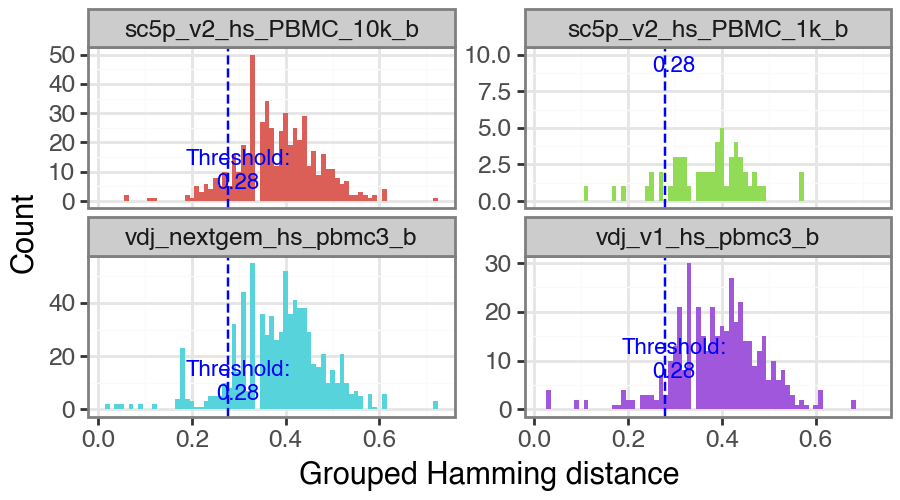

clone distance threshold: 0.27758454932603654


In [9]:
threshold = ddl.pp.calculate_threshold(vdj)
print(f"clone distance threshold: {threshold}")

You can also manually select a value as the threshold if you wish. Note that rerunning this with `manual_threshold` is just for reproducing the plot but with the line at 0.1 in this tutorial.

Calculating threshold


R[write to console]: Error in (function (db, sequenceColumn = "junction", vCallColumn = "v_call",  : 
  254 cell(s) with multiple heavy chains found. One heavy chain per cell is expected.



Rerun this after filtering. For now, switching to heavy mode.


R[write to console]: Running in non-single-cell mode.



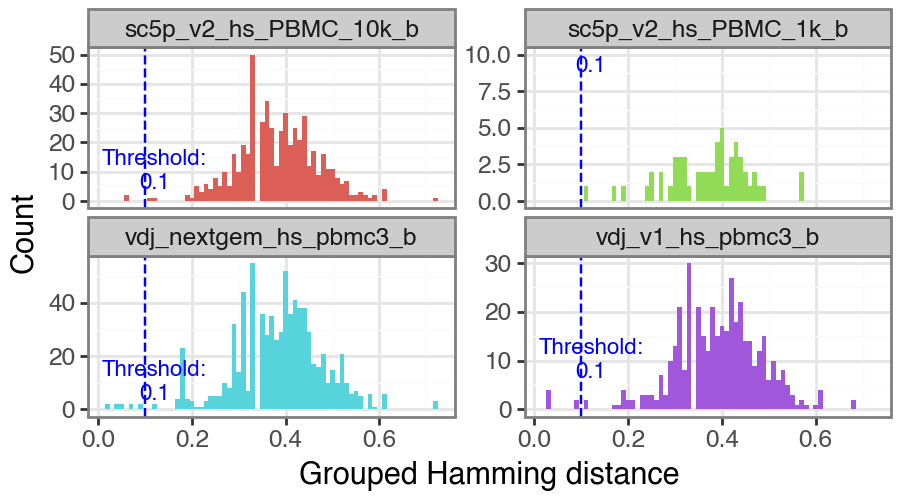

In [10]:
_ = ddl.pp.calculate_threshold(vdj, manual_threshold=0.1)


We can run `ddl.tl.define_clones` to call *changeo's* `DefineClones.py`; see [here](https://changeo.readthedocs.io/en/stable/methods/clustering.html) for more info. The value in dist option (corresponds to threshold value) needs to be manually supplied. Additional options for `ddl.tl.define_clones` to provide to `DefineClones.py` can be supplied as a list to the `additional_args` option.

In [11]:
# make a copy of the original vdj object to compare results
vdj_changeo = vdj.copy()
ddl.tl.define_clones(vdj_changeo, dist=threshold, key_added="changeo_clone_id")
vdj_changeo

Finding clones
Running command: DefineClones.py -d /var/folders/_r/j_8_fj3x28n2th3ch0ckn9c40000gt/T/tmpvj7nc9kd/tmp/dandelion_define_clones_heavy-clone.tsv -o /var/folders/_r/j_8_fj3x28n2th3ch0ckn9c40000gt/T/tmpvj7nc9kd/dandelion_define_clones_heavy-clone.tsv --act set --model ham --norm len --dist 0.27758454932603654 --nproc 1 --vf v_call_genotyped

       START> DefineClones
        FILE> dandelion_define_clones_heavy-clone.tsv
   SEQ_FIELD> junction
     V_FIELD> v_call_genotyped
     J_FIELD> j_call
 MAX_MISSING> 0
GROUP_FIELDS> None
      ACTION> set
        MODE> gene
    DISTANCE> 0.27758454932603654
     LINKAGE> single
       MODEL> ham
        NORM> len
         SYM> avg
       NPROC> 1

PROGRESS> [Grouping sequences] 20:37:30 (2404) 0.0 min

PROGRESS> [Assigning clones] 20:37:32 |####################| 100% (2,404) 0.0 min

 OUTPUT> dandelion_define_clones_heavy-clone.tsv
 CLONES> 2241
RECORDS> 2404
   PASS> 2404
   FAIL> 0
    END> DefineClones

 finished: Updated DandelionP

Lazy Dandelion object with n_obs = 2496 and n_contigs = 5767
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

Note that I specified the parameter `key_added` and this adds the clone id output from `ddl.tl.define_clones` into a separate column. If left as default (`None`), it will write into `clone_id` column. The same `key_added` parameter can be specified in `ddl.tl.find_clones` earlier. You will notice that `vdj_changeo` is initisalised with `changeo_clone_id` as the first column while `vdj` has `clone_id`.

## Other clustering methods
*dandelion* also now supports clustering methods from `scoper`. You can access the functions through:

```python
dandelion.external.immcancation.scoper.identical_clones(vdj, ...)
dandelion.external.immcancation.scoper.hierarchical_clones(vdj, ...)
dandelion.external.immcancation.scoper.spectral_clones(vdj, ...)
```

see the [dandelion documentation](https://sc-dandelion.readthedocs.io) for more information.

## Generation of V(D)J network
`dandelion` generates a network to facilitate visualisation of results, inspired from [[Bashford-Rogers2013]](https://genome.cshlp.org/content/23/11/1874). The deafult uses the full V(D)J contig amino acid sequences to chart a tree-like network for each clone, but it can also be used on any sequence columns, e.g. junctional nucleotide sequences. The actual visualization of the network is in the next tutorial.

`ddl.tl.generate_network` now accepts and returns `DandelionPolars` objects.

<div class="alert alert-info">

Reusing pre-computed distances

`generate_network` now automatically detects the pre-computed distance matrix in `vdj.distances` at the start. If `vdj.distances` exists (generated by `find_clones(store_distances=True)`), the entire distance computation step is skipped. This is logged as "Using pre-computed distances from .distances". If `vdj.distances` is `None`, the distances will be recomputed from scratch.

</div>



<div class="alert alert-info">

Layout Method Updates

Several new layout algorithm options are available:

| Method | Description |
|---|---|
| `mod_fr` | Original Python modified Fruchterman-Reingold layout |
| `mod_fr2` | **New default.** Numba-accelerated FR layout (faster on CPU) |
| `mod_fr2_gpu` | PyTorch GPU-accelerated FR (auto-tiles for >100K nodes) |
| `mod_fr_bh` | Barnes-Hut O(N log N) CPU layout (scalable for large graphs) |
| `mod_fr_bh_gpu` | Barnes-Hut GPU layout (requires CUDA) |
| `fa2` | ForceAtlas2 (requires `fa2-modified`) |

The `singleton_mass` parameter (default 0.5) controls the mass of isolated nodes in Barnes-Hut layouts. Lowering this reduces the repulsive force that singletons exert on connected components.

</div>

Before proceeding, let's do a bit of subsetting. Here I want to remove the `Orphan VJ` cells (lacking BCR heavy chain i.e. VDJ information). Whether or not you want to do this is up to you. I'm doing this because I want to focus on the BCR heavy chain for now. You may elect to keep everything and that can be your starting point for further analysis.

In [12]:
vdj = vdj[
    vdj.metadata["chain_status"].is_in(
        ["Single pair", "Extra pair", "Extra pair-exception", "Orphan VDJ"]
    )
].copy()
vdj

Lazy Dandelion object with n_obs = 2351 and n_contigs = 5597
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [13]:
ddl.tl.generate_network(vdj)

Generating network
Using pre-computed distances from .distances

Computing network layout


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:00:00)


### Full pairwise distance computation

With version 1.0.0, we are bringing back the option to compute the full pairwise distance matrix for every pair of cells. This is useful if you want to have a more comprehensive view of the relationships between cells, rather than just within clones. However, this can be quite memory intensive, especially for large datasets. For that purpose, we have refactored the distance computation to allow for parallelization, as well as with lazy evaluation using `dask` and `zarr` arrays, which allows for handling larger datasets without running into memory issues. This is particularly useful when calculating the full pairwise distance matrix for every pair of cells, which can be quite memory-intensive. While this can also be used for `distance_mode='clone'`, it's incredibly slow. Its main advantage is for `distance_mode='full'` due to contigous nature of the distance matrix.

Note that with `distance_mode='full'`, the required memory scales quadratically with the number of cells, so be cautious when using this option with large datasets. Using `dask` and `zarr` arrays can help mitigate this issue by allowing for out-of-core computation and parallel processing. This will create a `zarr` array on disk to store the distance matrix, which can later be read into memory in the `DandelionPolars` object with `vdj.compute()`, or specifying the path to the `zarr` array when reading the `DandelionPolars` object with `ddl.read_zipddl`.

<div class="alert alert-info">

`distance_mode` Options

| Mode | Description |
|---|---|
| `"clone"` | **Default.** Computes distances only within clones. Memory efficient, suitable for most use cases. |
| `"full"` | Computes full pairwise distances between all cells. Memory intensive — recommended to use with `lazy=True`. |

</div>

<div class="alert alert-info">

New Feature: Lazy Disk-Level Distance Computation

For large datasets, use `lazy=True` to offload distance computation to disk.

In lazy mode:
- The distance matrix is stored as a Zarr array on disk, with a Dask lazy view on top.
- `vdj.distances` returns a `dask.array.Array` that computes on demand.
- Call `vdj.compute()` to materialize it into an in-memory CSR sparse matrix.

`zarr_path` controls the storage location. If not specified, a temporary directory is created.

</div>

<div class="alert alert-warning">

When pre-computed CSR distances are detected, `lazy` is automatically forced to `False`, since the CSR matrix is already in memory and disk-level lazy loading is unnecessary. You can run `vdj.distances = None` to delete the pre-computed CSR distances.

</div>

Finally, while pairwise distance computation is now possible, the final graph and layout is still based on within-clone distances only for performance reasons i.e. it will behave as before. In the future, we may explore options to incorporate full pairwise distances into the graph construction and visualization. We will demonstrate alternative ways to visualise the full pairwise distances in a later tutorial where use use `UMAP` and `wnn` on the full distance matrix.

To be able to use `lazy=True`, you need to have `dask`, `zarr` and `distributed` installed in your environment.

```bash
pip install "sc-dandelion[dask]"
pip install ipywidgets
```

In [14]:
vdj.distances = None
vdj.distances

In [15]:
# we will demonstrate one example here where we use the lazy method to compute the network
vdj_lazy = vdj.copy()
ddl.tl.generate_network(
    vdj_lazy,
    use_existing_graph=False,
    distance_mode="full",
    lazy=True,
    n_cpus=8,
    zarr_path="distance_matrix.zarr",  # this is where the final computed distance matrix will be stored on disk
)

Generating network
Calculating distance matrix lazily with distance_mode = 'full'

Preparing distance matrix computation for 2351 sequences across 1 columns...
Auto-determined chunk size: 2351 (for 2351 sequences)

Created Zarr array at: distance_matrix.zarr
Dask client started: http://127.0.0.1:8787/status
Scattered DataFrame to workers
Starting computation of 1 chunks...
Merging temporary results into final Zarr array...


100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


Computing network layout
Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:09:55)


In [16]:
# view the vdj object
vdj_lazy

Lazy Dandelion object with n_obs = 2351 and n_contigs = 5597
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [ ]:
# save using the new default .zipddl format
vdj_lazy.write_zipddl("dandelion_results_lazy_distance_matrix.zipddl")

Because the distance matrix is lazy, it is not stored in the `.zipddl` file, but rather as the separate zarr array on disk in `zarr_path`. We will show you how to read this back in later.

### Caveats with lazy distance matrix computation

With `lazy=True`, the distance matrix computation will be performed lazily on disk, which allows for handling larger datasets without running into memory issues. This is particularly useful when calculating the full pairwise distance matrix for every pair of cells, which can be quite memory-intensive.

While this can also be used for `distance_mode='clone'`, it is not recommended for this mode as the distance matrix computation is already efficient enough for this mode.

In [18]:
# examine the .distances slot
vdj_lazy.distances

dask.array<from-zarr, shape=(2351, 2351), dtype=float64, chunksize=(2351, 2351), chunktype=numpy.ndarray>

In [19]:
# read distance matrix into memory
vdj_lazy.compute()
# now the distance matrix is in memory as a compressed sparse matrix
vdj_lazy.distances

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5526799 stored elements and shape (2351, 2351)>

At this point, we can save the dandelion object. We will visualise the network in the next tutorial.

In [20]:
vdj.write_zipddl("dandelion_results_simplified.zipddl")

In [21]:
# let's also transfer the new slots to the original files
vdj_original = ddl.read_zipddl("dandelion_results.zipddl")
vdj_original

Lazy Dandelion object with n_obs = 2496 and n_contigs = 5767
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [22]:
vdj_original.metadata = vdj.metadata.clone()
vdj_original.layout = vdj.layout
vdj_original.graph = vdj.graph
vdj_original

Lazy Dandelion object with n_obs = 2351 and n_contigs = 5767
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [23]:
# save
vdj_original.write_zipddl("dandelion_results.zipddl")

Finally, this is how you can read a `dandelion` object saved with lazy distance matrix computation. The distance matrix will still be a `zarr` array on disk, which you can compute into memory with `vdj.compute()` when needed.

In [24]:
vdj_lazy_reload = ddl.read_zipddl(
    "dandelion_results_lazy_distance_matrix.zipddl",
    distance_zarr="distance_matrix.zarr/distance_matrix.zarr",
)
vdj_lazy_reload

Lazy Dandelion object with n_obs = 2351 and n_contigs = 5597
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [25]:
vdj_lazy_reload.compute()
vdj_lazy_reload

Lazy Dandelion object with n_obs = 2351 and n_contigs = 5597
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [26]:
vdj_lazy_reload.distances

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5526799 stored elements and shape (2351, 2351)>